In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml

from sklearn.manifold import TSNE

from sklearn.model_selection import StratifiedKFold

%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split

import plotly.express as px

# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.manifold import TSNE
# from sklearn.datasets import load_iris  # Можно заменить на ваш набор данных
# import pandas as pd
# import seaborn as sns

In [3]:
X, y  = fetch_openml('SignMNIST',
                     version=1,
                     return_X_y=True,
                     parser='auto')
# нормализуем, так как изображения имеют значения от 0 до 255
X = X / 255
X.shape

(34627, 784)

In [6]:
# Let's use a smaller subset for faster visualization
# SignMNIST is much larger than Iris
n_samples = 2000  # Adjust this number based on your computational resources
indices = np.random.choice(X.shape[0], n_samples, replace=False)
X_subset = X.iloc[indices].values
y_subset = y[indices]

In [7]:
# Get unique labels
unique_labels = np.unique(y_subset)
target_names = [f'Sign {label}' for label in unique_labels]

In [8]:
# Apply t-SNE with different perplexity values
perplexities = [5, 30, 50]
plt.figure(figsize=(15, 5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

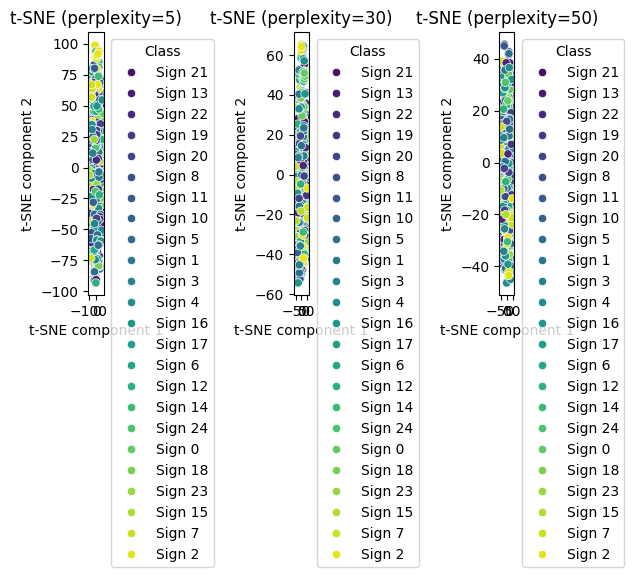

In [9]:
for i, perplexity in enumerate(perplexities):
    # Apply t-SNE
    tsne = TSNE(n_components=2, perplexity=perplexity,
                random_state=42, max_iter=1000, learning_rate='auto')
    tsne_results = tsne.fit_transform(X_subset)

    # Create DataFrame for visualization
    df_tsne = pd.DataFrame({
        'x': tsne_results[:, 0],
        'y': tsne_results[:, 1],
        'label': [f'Sign {label}' for label in y_subset]
    })

    # Visualization with class highlighting
    plt.subplot(1, 3, i+1)
    sns.scatterplot(x='x', y='y', hue='label', data=df_tsne, palette='viridis')
    plt.title(f't-SNE (perplexity={perplexity})')
    plt.xlabel('t-SNE component 1')
    plt.ylabel('t-SNE component 2')
    plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [10]:
# Detailed visualization with optimal perplexity
# Choose optimal value based on previous visualizations
optimal_perplexity = 30  # Adjust based on results

tsne = TSNE(n_components=2, perplexity=optimal_perplexity,
            random_state=42, max_iter=1000, learning_rate='auto')
tsne_results = tsne.fit_transform(X_subset)

In [11]:
# Create DataFrame for visualization
df_tsne = pd.DataFrame({
    'x': tsne_results[:, 0],
    'y': tsne_results[:, 1],
    'label': [f'Sign {label}' for label in y_subset]
})

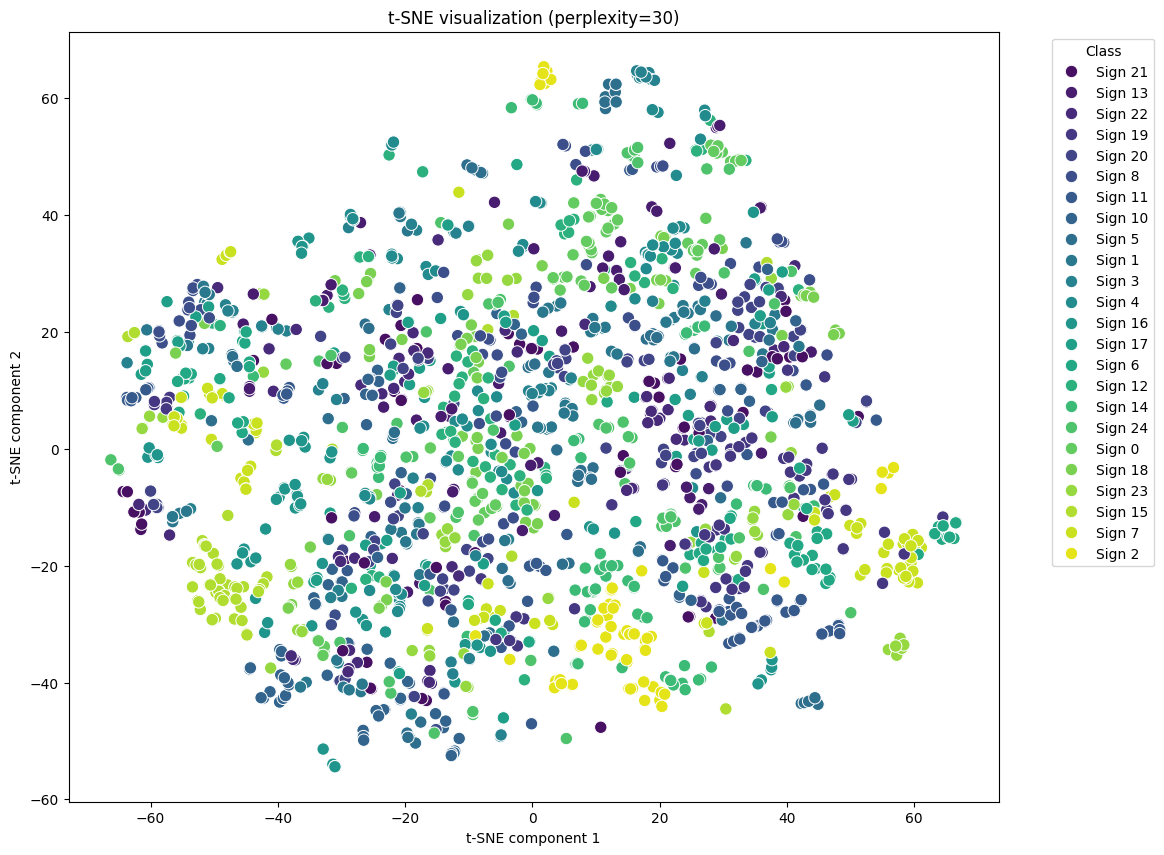

In [12]:
# Detailed visualization
plt.figure(figsize=(12, 10))
sns.scatterplot(x='x', y='y', hue='label', data=df_tsne, palette='viridis', s=80)
plt.title(f't-SNE visualization (perplexity={optimal_perplexity})')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()